# LCC paper figures

This notebook reproduces all main figures for the paper. It is divided into two sections: (1) synthetic GPR validation and (2) real Findelen glacier data. Each section expects pre-computed LCC results on disk — run `run_synthetic.py` and `run_findelen.py` first.

In [ ]:
import matplotlib
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat 
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib import patheffects as path_effects
pe = [path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()]

## Synthetic GPR data

We use a synthetic GPR dataset in which the true deformation field is known, allowing us to validate the LCC estimates against ground truth. We load the migrated synthetic GPR image from an xarray NetCDF and the ground-truth deformation field from the forward simulation from matlab.

In [3]:
path = 'data/synthetic_findelen/synth2_migrated_gridded.nc'
da = xr.load_dataarray(path)

In [ ]:
tmp = loadmat('data/synthetic_findelen/data_subset_1100_1400.mat', simplify_cells=True)['data']
X = np.stack([tmp['X'], tmp['Y']])
V = np.stack([tmp['v_x'], tmp['v_y']])

In [ ]:
# here we will manipulate the coordinates
xx, dd = np.meshgrid(da.x, da.t)

# we interpolate the elevation of the surface and the bed on the coordinates of the gpr
from scipy.interpolate import interp1d
zf = interp1d(tmp['x'], tmp['zs_hr'])
bedf = interp1d(tmp['x'], tmp['bed_hr'])

gprz = zf(da.x)
gprbed = bedf(da.x)
zz = gprz[0] - dd

We plot the two time lapse of the GPR images.

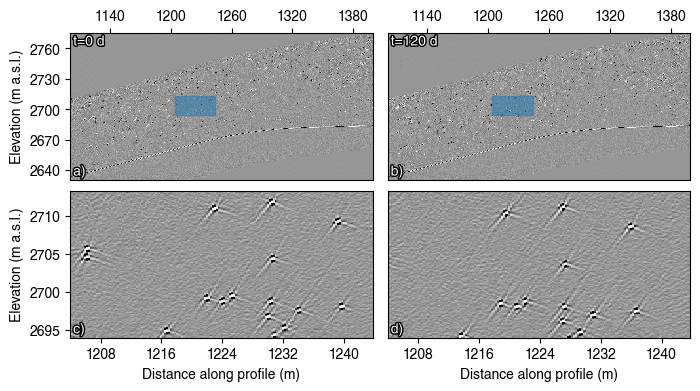

In [7]:
from matplotlib.patches import Rectangle
%matplotlib inline
vmax = np.quantile(np.abs(da), 0.995)

# the grid has a 2x2 size, where we plot the before and after gpr images on the left and right
fig, axs = plt.subplots(2, 2, figsize=(8, 4))
axs[0, 0].pcolormesh(xx, zz, da.isel(date=0, ori=0), cmap='Greys', vmin=-vmax, vmax=vmax, rasterized=True)
axs[1, 0].pcolormesh(xx, zz, da.isel(date=0, ori=0), cmap='Greys', vmin=-vmax, vmax=vmax, rasterized=True)

# the bottom row will be zoomed in
axs[0, 1].pcolormesh(xx, zz, da.isel(date=1, ori=0), cmap='Greys', vmin=-vmax, vmax=vmax, rasterized=True)
axs[1, 1].pcolormesh(xx, zz, da.isel(date=1, ori=0), cmap='Greys', vmin=-vmax, vmax=vmax, rasterized=True)

# we write 'before' and 'after' on the left and right plots
axs[0, 0].text(0.01, 0.99, 't=0 d', c='w', ha='left', va='top', transform=axs[0, 0].transAxes, path_effects=pe)
axs[0, 1].text(0.01, 0.99, 't=120 d', c='w', ha='left', va='top', transform=axs[0, 1].transAxes, path_effects=pe)

for ax in axs.flatten():
    ax.set_aspect(1)

# we want the right most axis to hide the yticks
for ax in axs[:, -1]:
    ax.set_yticks([])

# we will zoom in on the bottom row while keeping the aspect ratio
ylim = axs[0, 0].get_ylim()
xlim = axs[0, 0].get_xlim()
scale = 7.5
yfactor = (ylim[1] - ylim[0]) / scale
xfactor = (xlim[1] - xlim[0]) / scale

# datum coordinates for the zoom in
x0 = 1204
y0 = 2694

# we plot a rectangle on the top row to show where we zoom in
for ax in axs[0, :]:
    rect = Rectangle([x0, y0], xfactor, yfactor, ec='tab:blue', facecolor='tab:blue', alpha=0.5)
    ax.add_patch(rect)

# we zoom in on the bottom row
for ax in axs[-1, :]:
    ax.set_ylim(y0, y0 + yfactor)
    ax.set_xlim(x0, x0 + xfactor)

# we limit the number of x and yticks
axs[0, 0].yaxis.set_major_locator(plt.MaxNLocator(5))
axs[1, 0].yaxis.set_major_locator(plt.MaxNLocator(4))
for ax in axs.flatten():
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))

for ax in axs[:, 0]:
    ax.set_ylabel('Elevation (m a.s.l.)')
    
for ax in axs[-1, :]:
    ax.set_xlabel('Distance along profile (m)')

for ax in axs[0, :]:
    ax.xaxis.tick_top()

letters = 'abcd'
for i, ax in enumerate(axs.flatten()):
    ax.text(0.01, 0.01, f'{letters[i]})', ha='left', va='bottom', transform=ax.transAxes, c='w', path_effects=pe)

fig.subplots_adjust(wspace=0.05, hspace=0.05)
fig.savefig('figures/paper_figures/model2_mig_zoom.pdf', bbox_inches='tight')
fig.patch.set_facecolor('none')
fig.savefig('figures/paper_figures/model2_mig_zoom.png', bbox_inches='tight', transparent=True)

### LCC results

Load the pre-computed LCC output produced by `run_synthetic.py`. Run that script first if the file is not present.

In [8]:
import torch
import io
import pickle

class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else:
            return super().find_class(module, name)

with open(f'data/synthetic_findelen/out2_migrated_gridded_parallel.p', 'rb') as out:
    out = CPU_Unpickler(out).load()
    Vhat = out['out']
    lcc = out['lcc']
    losses = out['losses']

    print(lcc.f.shape)
    print(lcc.convolutions.shape)
    print(out['out'].shape)

torch.Size([1808, 1193])
torch.Size([51, 51, 452, 298])
(21, 2, 452, 298)


In [9]:
# we do this process again because now the coordinates will be relative to the LCC dimensions
gprx = da.x[:-1:lcc.stride] # da.x[::-1]
gprd = da.t[:-1:lcc.stride] # da.t[:]
xx, dd = np.meshgrid(gprx, gprd)

# we interpolate the elevation of the surface and the bed on the coordinates of the gpr
from scipy.interpolate import interp1d
zf = interp1d(tmp['x'], tmp['zs_hr'])
bedf = interp1d(tmp['x'], tmp['bed_hr'])

gprz = zf(gprx)
gprbed = bedf(gprx)
zz = gprz[0] - dd

dx = (gprx[1] - gprx[0]).values
dt = (gprd[1] - gprd[0]).values
dz = dt

print(len(gprx), len(gprd))
print(dx, dt, dz)

298 452
1.0 0.3207134902949207 0.3207134902949207


In [ ]:
# we interpolate the velocity field to the grid used by the LCC
from scipy.interpolate import RegularGridInterpolator
Vxf = RegularGridInterpolator((tmp['x'], tmp['y']), V[0].T, bounds_error=False, fill_value=None)
Vyf = RegularGridInterpolator((tmp['x'], tmp['y']), V[1].T, bounds_error=False, fill_value=None)

Vxgrid = Vxf((xx, zz))
Vygrid = Vyf((xx, zz))

We show the estimated velocity field from the different LCC steps.

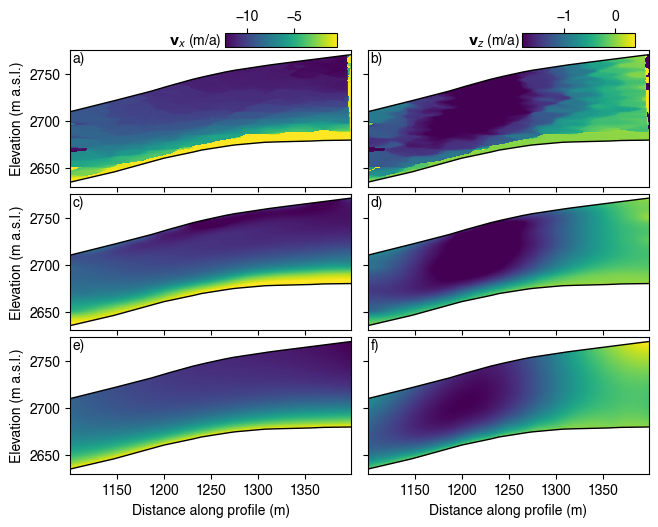

In [ ]:
%matplotlib inline
from torch.nn import functional as F
from matplotlib.colors import Normalize

under_surface = zz < gprz
above_bed = zz > gprbed
mask = under_surface & above_bed
mask = mask.astype(float)
mask[mask == 0] = np.nan    

def plot_field(xx, zz, v, ax, norm, alpha=None):   
    #ax.pcolormesh(xx, zz, v, norm=norm, alpha=0.5, rasterized=True)
    im = ax.pcolormesh(xx, zz, v * mask, norm=norm, rasterized=True)#, alpha=confidence)
    ax.set_aspect(1)
    ax.plot(gprx, gprz, c='k', lw=1)
    ax.plot(gprx, gprbed, c='k', lw=1)
    return im

xnorm = Normalize(vmin=np.nanmin(Vxgrid), vmax=np.nanmax(Vxgrid))
ynorm = Normalize(vmin=np.nanmin(Vygrid), vmax=np.nanmax(Vygrid))
magnorm = Normalize(vmin=np.nanmin(np.hypot(Vxgrid, Vygrid)), vmax=np.nanmax(np.hypot(Vxgrid, Vygrid)))

fig, axs = plt.subplots(3, 2, figsize=(7.5, 5.5), sharex='all', sharey='all')
fig.subplots_adjust(wspace=0.05, hspace=0.05)

Vhatx0 = lcc.subdw.numpy() * dx / (120 / 365) / lcc.stride
Vhatx0 = F.interpolate(torch.tensor(Vhatx0).reshape(1, 1, *Vhatx0.shape), Vxgrid.shape, mode='nearest')[0, 0].numpy()

Vhaty0 = - lcc.subdh.numpy() * dt / (120 / 365) / lcc.stride
Vhaty0 = F.interpolate(torch.tensor(Vhaty0).reshape(1, 1, *Vhaty0.shape), Vxgrid.shape, mode='nearest')[0, 0].numpy()

Vhatx2 = out['out'][-1, 0] * dx / (120 / 365) / lcc.stride
Vhaty2 = - out['out'][-1, 1] * dt / (120 / 365) / lcc.stride

plot_field(xx, zz, Vhatx0, axs[0, 0], norm=xnorm)
plot_field(xx, zz, Vhaty0, axs[0, 1], norm=ynorm)

plot_field(xx, zz, Vhatx2, axs[1, 0], norm=xnorm)
plot_field(xx, zz, Vhaty2, axs[1, 1], norm=ynorm)

vxim = plot_field(xx, zz, Vxgrid, axs[2, 0], norm=xnorm)
vyim = plot_field(xx, zz, Vygrid, axs[2, 1], norm=ynorm)

for ax in axs[-1, :]:
    ax.set_xlabel('Distance along profile (m)')
for ax in axs[:, 0]:
    ax.set_ylabel('Elevation (m a.s.l.)')

bbox = axs[0, 0].get_position()
cax_length = 0.4 
vxcax = fig.add_axes([bbox.x0 + (0.95 - cax_length) * bbox.width, bbox.y1 + 0.025 * bbox.height, cax_length * bbox.width, 0.1 * bbox.height])
plt.colorbar(vxim, cax=vxcax, orientation='horizontal')
vxcax.xaxis.tick_top()
vxcax.text(-0.025, 0.5, '$\mathbf{v}_x$ (m/a)', ha='right', va='center', transform=vxcax.transAxes)

bbox = axs[0, -1].get_position()
cax_length = 0.4 
vxcax = fig.add_axes([bbox.x0 + (0.95 - cax_length) * bbox.width, bbox.y1 + 0.025 * bbox.height, cax_length * bbox.width, 0.1 * bbox.height])
plt.colorbar(vyim, cax=vxcax, orientation='horizontal')
vxcax.xaxis.tick_top()
vxcax.text(-0.025, 0.5, '$\mathbf{v}_z$ (m/a)', ha='right', va='center', transform=vxcax.transAxes)

letters = 'abcdefghijklmnop'
for i, ax in enumerate(axs.flatten()):
    ax.text(0.01, 0.99, f'{letters[i]})', ha='left', va='top', transform=ax.transAxes)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

fig.savefig('figures/paper_figures/synthetic_fields.pdf', bbox_inches='tight')
fig.patch.set_facecolor('none')
fig.savefig('figures/paper_figures/synthetic_fields.png', bbox_inches='tight')


An older version of the figure that didn't make it to the paper, showing the median filter step as well as a vector field.

"fig.savefig('figures/paper_figures/synthetic_fields.pdf', bbox_inches='tight')\nfig.patch.set_facecolor('none')\nfig.savefig('figures/paper_figures/synthetic_fields.png', bbox_inches='tight')"

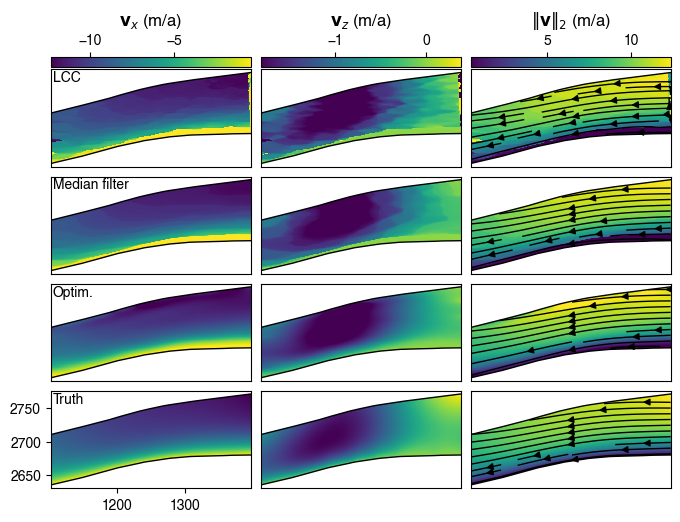

In [14]:
%matplotlib inline
from torch.nn import functional as F
from matplotlib.colors import Normalize

plt.close('all')

under_surface = zz < gprz
above_bed = zz > gprbed
mask = under_surface & above_bed
mask = mask.astype(float)
mask[mask == 0] = np.nan    

def plot_field(xx, zz, v, ax, norm, alpha=None):   
    #ax.pcolormesh(xx, zz, v, norm=norm, alpha=0.5, rasterized=True)
    im = ax.pcolormesh(xx, zz, v * mask, norm=norm, rasterized=True)#, alpha=confidence)
    ax.set_aspect(1)
    ax.plot(gprx, gprz, c='k', lw=1)
    ax.plot(gprx, gprbed, c='k', lw=1)
    return im

xnorm = Normalize(vmin=np.nanmin(Vxgrid), vmax=np.nanmax(Vxgrid))
ynorm = Normalize(vmin=np.nanmin(Vygrid), vmax=np.nanmax(Vygrid))
magnorm = Normalize(vmin=np.nanmin(np.hypot(Vxgrid, Vygrid)), vmax=np.nanmax(np.hypot(Vxgrid, Vygrid)))

fig, axs = plt.subplots(4, 3, figsize=(8, 5.5))
fig.subplots_adjust(wspace=0.05, hspace=0.05)

Vhatx0 = lcc.subdw.numpy() * dx / (120 / 365) / lcc.stride
Vhatx0 = F.interpolate(torch.tensor(Vhatx0).reshape(1, 1, *Vhatx0.shape), Vxgrid.shape, mode='nearest')[0, 0].numpy()

Vhaty0 = - lcc.subdh.numpy() * dt / (120 / 365) / lcc.stride
Vhaty0 = F.interpolate(torch.tensor(Vhaty0).reshape(1, 1, *Vhaty0.shape), Vxgrid.shape, mode='nearest')[0, 0].numpy()

Vhatx1 = out['out'][0, 0] * dx / (120 / 365) / lcc.stride
Vhaty1 = - out['out'][0, 1] * dt / (120 / 365) / lcc.stride

Vhatx2 = out['out'][-1, 0] * dx / (120 / 365) / lcc.stride
Vhaty2 = - out['out'][-1, 1] * dt / (120 / 365) / lcc.stride

plot_field(xx, zz, Vhatx0, axs[0, 0], norm=xnorm)
plot_field(xx, zz, Vhaty0, axs[0, 1], norm=ynorm)
plot_field(xx, zz, np.hypot(Vhatx0, Vhaty0), axs[0, 2], norm=magnorm)
axs[0, 2].streamplot(xx, zz[::-1], (Vhatx0 * mask)[::-1], (Vhaty0 * mask)[::-1], color='k', linewidth=1, density=0.6)

plot_field(xx, zz, Vhatx1, axs[1, 0], norm=xnorm)
plot_field(xx, zz, Vhaty1, axs[1, 1], norm=ynorm)
plot_field(xx, zz, np.hypot(Vhatx1, Vhaty1), axs[1, 2], norm=magnorm)
axs[1, 2].streamplot(xx, zz[::-1], (Vhatx1 * mask)[::-1], (Vhaty1 * mask)[::-1], color='k', linewidth=1, density=0.6)

plot_field(xx, zz, Vhatx2, axs[2, 0], norm=xnorm)
plot_field(xx, zz, Vhaty2, axs[2, 1], norm=ynorm)
plot_field(xx, zz, np.hypot(Vhatx2, Vhaty2), axs[2, 2], norm=magnorm)
axs[2, 2].streamplot(xx, zz[::-1], (Vhatx2 * mask)[::-1], (Vhaty2 * mask)[::-1], color='k', linewidth=1, density=0.6)

vxim = plot_field(xx, zz, Vxgrid, axs[3, 0], norm=xnorm)
vyim = plot_field(xx, zz, Vygrid, axs[3, 1], norm=ynorm)
vmim = plot_field(xx, zz, np.hypot(Vxgrid, Vygrid), axs[3, 2], norm=magnorm)
axs[3, 2].streamplot(xx, zz[::-1], (Vxgrid * mask)[::-1], (Vygrid * mask)[::-1], color='k', linewidth=1, density=0.6)

axs[0, 0].text(0.01, 0.99, 'LCC', ha='left', va='top', transform=axs[0, 0].transAxes)
axs[1, 0].text(0.01, 0.99, 'Median filter', ha='left', va='top', transform=axs[1, 0].transAxes)
axs[2, 0].text(0.01, 0.99, 'Optim.', ha='left', va='top', transform=axs[2, 0].transAxes)
axs[3, 0].text(0.01, 0.99, 'Truth', ha='left', va='top', transform=axs[3, 0].transAxes)

for i, ax in enumerate(axs.flatten()):
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(zz.min(), zz.max())
    if i != 9:
        ax.set_xticks([])
        ax.set_yticks([])



bbox = axs[0, 0].get_position()
vxcax = fig.add_axes([bbox.x0, bbox.y1 + 0.025 * (bbox.y1 - bbox.y0), bbox.x1 - bbox.x0, 0.1 * (bbox.y1 - bbox.y0)])
plt.colorbar(vxim, cax=vxcax, orientation='horizontal')
vxcax.xaxis.tick_top()
vxcax.set_title('$\mathbf{v}_x$ (m/a)')

bbox = axs[0, 1].get_position()
vycax = fig.add_axes([bbox.x0, bbox.y1 + 0.025 * (bbox.y1 - bbox.y0), bbox.x1 - bbox.x0, 0.1 * (bbox.y1 - bbox.y0)])
plt.colorbar(vyim, cax=vycax, orientation='horizontal')
vycax.xaxis.tick_top()
vycax.set_title('$\mathbf{v}_z$ (m/a)')

bbox = axs[0, 2].get_position()
vmcax = fig.add_axes([bbox.x0, bbox.y1 + 0.025 * (bbox.y1 - bbox.y0), bbox.x1 - bbox.x0, 0.1 * (bbox.y1 - bbox.y0)])
plt.colorbar(vmim, cax=vmcax, orientation='horizontal')
vmcax.xaxis.tick_top()
vmcax.set_title('$\Vert \mathbf{v} \Vert_2$ (m/a)')

'''fig.savefig('figures/paper_figures/synthetic_fields.pdf', bbox_inches='tight')
fig.patch.set_facecolor('none')
fig.savefig('figures/paper_figures/synthetic_fields.png', bbox_inches='tight')'''


This plot was an attempt at showing the distribution of error vs the true displacement. 

Text(0, 0.5, 'error (m)')

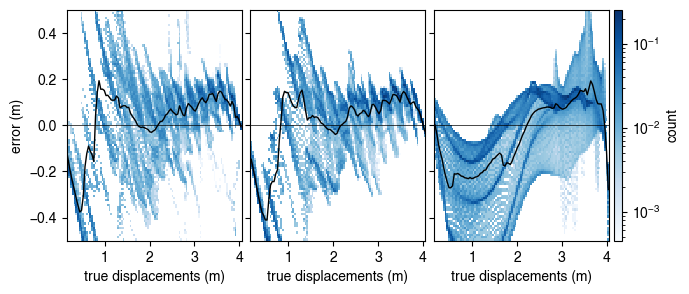

In [15]:
lapsed_time = (120/365)
fig, axs = plt.subplots(1, 3, sharey='all', figsize=(7, 3))
urange = np.array([magnorm.vmin, magnorm.vmax]) * lapsed_time
lapsed_time = 120/365

truth = np.hypot(Vxgrid, Vygrid)
x = truth[mask == 1] * lapsed_time
estimates = [np.hypot(Vhatx0, Vhaty0), np.hypot(Vhatx1, Vhaty1), np.hypot(Vhatx2, Vhaty2)]

for i, ax in enumerate(axs):
    estimate = estimates[i] # np.hypot(Vhatx2, Vhaty2)
    
    err = (estimate[mask == 1] - truth[mask == 1]) * lapsed_time
    H, xedges, yedges = np.histogram2d(x, err, 
               range=[urange, [-0.5, 0.5]], bins=[100, 100])
    
    axis = 1
    H = H/H.sum(axis=1, keepdims=True)
    
    ypos = (yedges[1:] + yedges[:-1]) / 2
    xpos = (xedges[1:] + xedges[:-1]) / 2
    mean = np.sum(H * ypos, axis=axis) / H.sum(axis=axis)
    
    im = ax.pcolormesh(xedges, yedges, H.T, cmap='Blues', shading='flat', norm='log')
    ax.plot(urange, [0, 0], c='k', lw=0.5)
    
    #ax.set_aspect(1)
    ax.set_xlabel('true displacements (m)')
    #ax.set_yticks([-0.5, 0.0, 0.5, 1.0])
    #ax.plot(xpos, mean, c='k', lw=1, label='mean')
    ax.plot(xpos, mean, c='k', lw=1, label='median')
    #ax.legend(loc='lower left')

fig.subplots_adjust(wspace=0.05)
bbox = axs[-1].get_position()
cax = fig.add_axes([bbox.x1 + bbox.width * 0.025, bbox.y0, bbox.width * 0.05, bbox.height])
plt.colorbar(im, cax=cax)
cax.set_ylabel('count')
axs[0].set_ylabel('error (m)')


This plot made it into the paper, where we're showing the distribution of error through the synthetic domain. We're also looking at the error from the forward model, as well as the maximum cross-correlation maps. Those last two maps provide guidance in interpreting the velocity fields.

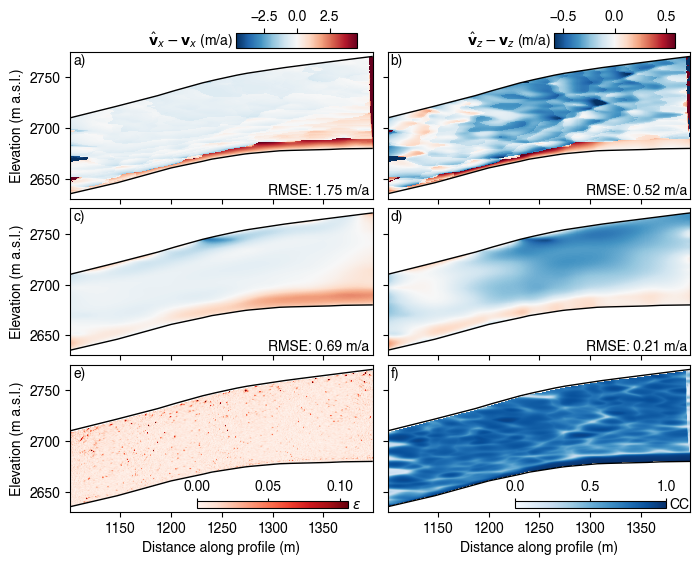

In [18]:
%matplotlib inline
from torch.nn import functional as F
from matplotlib.colors import Normalize

under_surface = zz < gprz
above_bed = zz > gprbed
mask = under_surface & above_bed
mask = mask.astype(float)
mask[mask == 0] = np.nan    
mag = np.hypot(Vxgrid, Vygrid)


def plot_field(xx, zz, v, ax, norm, cmap='RdBu_r', alpha=None, levels=None):   
    #ax.pcolormesh(xx, zz, v, norm=norm, alpha=0.5, rasterized=True)
    im = ax.pcolormesh(xx, zz, v * mask, norm=norm, rasterized=True, cmap=cmap)#, alpha=confidence)
    rmse = np.sqrt(np.nanmean(np.square(v * mask)))
    #im = ax.contourf(xx, zz, v * mask, norm=norm, cmap=cmap, )
    ax.set_aspect(1)
    ax.plot(gprx, gprz, c='k', lw=1)
    ax.plot(gprx, gprbed, c='k', lw=1)

    ax.text(0.99, 0.01, f'RMSE: {rmse:.2f} m/a', ha='right', va='bottom', transform=ax.transAxes)

    return im

fig, axs = plt.subplots(3, 2, figsize=(8, 6), sharex='all', sharey='all')
fig.subplots_adjust(wspace=0.05, hspace=0.05)

Vhatx0 = lcc.subdw.numpy() * dx / (120 / 365) / lcc.stride
#Vhatx0 = F.interpolate(torch.tensor(Vhatx0).reshape(1, 1, *Vhatx0.shape), Vxgrid.shape, mode='nearest')[0, 0].numpy()

Vhaty0 = - lcc.subdh.numpy() * dt / (120 / 365) / lcc.stride
#Vhaty0 = F.interpolate(torch.tensor(Vhaty0).reshape(1, 1, *Vhaty0.shape), Vxgrid.shape, mode='nearest')[0, 0].numpy()

Vhatx2 = out['out'][-1, 0] * dx / (120 / 365) / lcc.stride
Vhaty2 = - out['out'][-1, 1] * dt / (120 / 365) / lcc.stride
Vhatmag2 = np.hypot(Vhatx2, Vhaty2)

xnorm = Normalize(vmin=-4.6, vmax=4.6)
ynorm = Normalize(vmin=-0.59, vmax=0.59)
magnorm = Normalize(vmin=-2.6, vmax=2.6)

plot_field(xx, zz, Vhatx0 - Vxgrid, axs[0, 0], norm=xnorm)
plot_field(xx, zz, Vhaty0 - Vygrid, axs[0, 1], norm=ynorm)

imx = plot_field(xx, zz, Vhatx2 - Vxgrid, axs[1, 0], norm=xnorm)
imy = plot_field(xx, zz, Vhaty2 - Vygrid, axs[1, 1], norm=ynorm)

for ax in axs[-1, :]:
    ax.set_xlabel('Distance along profile (m)')
for ax in axs[:, 0]:
    ax.set_ylabel('Elevation (m a.s.l.)')

bbox = axs[0, 0].get_position()
cax_length = 0.4 
vxcax = fig.add_axes([bbox.x0 + (0.95 - cax_length) * bbox.width, bbox.y1 + 0.025 * bbox.height, cax_length * bbox.width, 0.1 * bbox.height])
plt.colorbar(imx, cax=vxcax, orientation='horizontal')
vxcax.xaxis.tick_top()
vxcax.text(-0.025, 0.5, '$\hat{\mathbf{v}}_x - \mathbf{v}_x$ (m/a)', ha='right', va='center', transform=vxcax.transAxes)

bbox = axs[0, -1].get_position()
cax_length = 0.4 
vxcax = fig.add_axes([bbox.x0 + (0.95 - cax_length) * bbox.width, bbox.y1 + 0.025 * bbox.height, cax_length * bbox.width, 0.1 * bbox.height])
plt.colorbar(imy, cax=vxcax, orientation='horizontal')
vxcax.xaxis.tick_top()
vxcax.text(-0.025, 0.5,'$\hat{\mathbf{v}}_z - \mathbf{v}_z$ (m/a)', ha='right', va='center', transform=vxcax.transAxes)


for i, im in enumerate([error, lcc.convolutions.numpy().max(axis=(0, 1))]):
    im = axs[-1, i].imshow(im * mask, cmap=['Reds', 'Blues'][i], 
                       extent=[xx.min(), xx.max(), zz.min(), zz.max()], 
                       vmin=0, vmax=[errmax, 1.0][i])
    axs[-1, i].plot(gprx, gprz, c='k', lw=1)
    axs[-1, i].plot(gprx, gprbed, c='k', lw=1)
    bbox = axs[-1, i].get_position()
    cax = fig.add_axes([bbox.x0 + 0.42 * bbox.width, bbox.y0 + 0.025 * bbox.height,
                        0.5 * bbox.width, 0.05 * bbox.height])
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cax.xaxis.tick_top()
    cax.tick_params('x', length=2)
    cax.text(1.025, 0.5, ['$\epsilon$', 'CC'][i], ha='left', va='center', transform=cax.transAxes)

letters = 'abcdefghijklmnop'
for i, ax in enumerate(axs.flatten()):
    ax.text(0.01, 0.99, f'{letters[i]})', ha='left', va='top', transform=ax.transAxes, c='k')#, path_effects=pe)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

fig.savefig('figures/paper_figures/synthetic_fields_err.pdf', bbox_inches='tight')
fig.patch.set_facecolor('none')
fig.savefig('figures/paper_figures/synthetic_fields_err.png', bbox_inches='tight')


This figure didn't make it into the paper but I meant to keep it so that people could appreciate it's over-engineering.

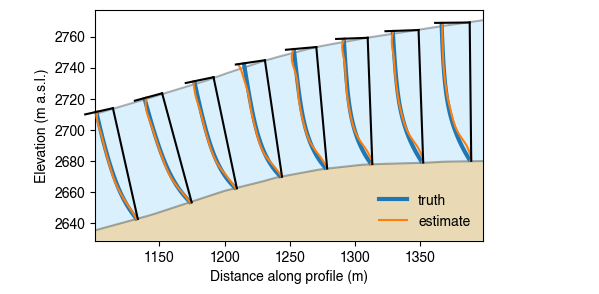

In [ ]:
%matplotlib inline

import numpy as np
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
import mpl_toolkits.axisartist.floating_axes as floating_axes
from matplotlib.transforms import Affine2D

Vhatx2 = out['out'][-1, 0] * dx / (120 / 365) / lcc.stride
Vhaty2 = - out['out'][-1, 1] * dt / (120 / 365) / lcc.stride

# we initially define a number of profiles to sample along the surface
n_samples = 8 
surface_points = np.linspace(15, len(gprx) - 11, n_samples).astype(int)

# we precompute the velocity magnitude for the true (1) and observed (2) velocity fields
velocity_magnitude1 = np.hypot(Vxgrid, Vygrid)  # Magnitude of velocity
velocity_magnitude2 = np.hypot(Vhatx2, Vhaty2)  # Magnitude of velocity

velocity_interpolator1 = RegularGridInterpolator((xx[0], zz[::-1, 0]), 
                                                 velocity_magnitude1[::-1].T,
                                                 bounds_error=False,   
                                                 fill_value=np.nan )

velocity_interpolator2 = RegularGridInterpolator((xx[0], zz[::-1, 0]), 
                                                 velocity_magnitude2[::-1].T,
                                                 bounds_error=False,   
                                                 fill_value=np.nan )

# we sample a number of points along the depth of the ice
depth_points = 100  
velocity_profiles1 = []
velocity_profiles2 = []
profile_lines = [] 

for idx in surface_points:
    
    #initial point for the surface 
    x_s, z_s = gprx[idx], gprz[idx]
    
    # we find the closest (a crude approximation of perpendicularity)
    distances = np.sqrt((gprx - x_s) ** 2 + (gprbed - z_s) ** 2)
    closest_idx = distances.argmin()
    x_b, z_b = gprx[closest_idx], gprbed[closest_idx]
    
    # we interpolate the points along the profile
    line_x = np.linspace(x_s, x_b, depth_points)
    line_z = np.linspace(z_s, z_b, depth_points)
    profile_lines.append((line_x, line_z))
    
    # we interpolate the velocities at those points
    sampled_velocities1 = velocity_interpolator1(np.array([line_x, line_z]).T)
    sampled_velocities2 = velocity_interpolator2(np.array([line_x, line_z]).T)
    velocity_profiles1.append(sampled_velocities1)
    velocity_profiles2.append(sampled_velocities2)

# we plot the glacier geometry
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(gprx, gprz, color='k', alpha=0.3)
ax.plot(gprx, gprbed, color='k', alpha=0.3)
ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.fill_between(gprx, gprz, gprbed, fc='lightskyblue', alpha=0.3)
ax.fill_between(gprx, ylim[0], gprbed, fc='darkgoldenrod', alpha=0.3)
ax.set_xlim(gprx.min(), gprx.max())

# the velocity profiles are in their own local coordinates. we need to create a new axis everytime.
for i, line in enumerate(profile_lines):
    line_x, line_z = line
        
    # we compute the angle of the profile
    DX = line_x[-1] - line_x[0]
    DZ = line_z[-1] - line_z[0]
    angle = np.arctan2(DZ, DX)  

    # creation of the axis
    width =  0.1 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # Scale width
    profile_length = np.sqrt(DX**2 + DZ**2)
    height = profile_length

    # the center point of the line and the dimensions of the axis
    x0 = np.array([line_x.mean(), line_z.mean()])
    w0 = np.array([width, height])
    
    # we compute the coordinates of the new axis
    x, y = fig.transFigure.inverted().transform(ax.transData.transform(x0))
    xo, yo = fig.transFigure.inverted().transform(ax.transData.transform(x0 + w0))
    h0 = w0 = np.sqrt((xo - x) ** 2 + (yo - y) ** 2)   

    # we create the new axis. it must be squared, ie. xmax-xmin = ymax-ymin
    xmin, xmax = -1., 1.                           
    ymin, ymax = -1., 1.                      
    transform = Affine2D().rotate(angle + np.pi/2)
    helper = floating_axes.GridHelperCurveLinear(transform, (xmin, xmax, ymin, ymax))
    ax2 = floating_axes.FloatingSubplot(fig, 111, grid_helper=helper, zorder=0)
    
    # we rotate the axis accordingly
    R = transform.transform([(x - w0 / 2, y - h0 / 2),
                             (x + w0 / 2, y - h0 / 2),
                             (x - w0 / 2, y + h0 / 2),
                             (x + w0 / 2, y + h0 / 2),])
    
    # we compute the width and height of axis
    w1 = R[:, 0].max() - R[:, 0].min()                  
    h1 = R[:, 1].max() - R[:, 1].min()                  
    
    # we put it at the right position
    ax2.set_position((x - w1 / 2, y - h1 / 2, w1, h1))
    fig.add_subplot(ax2)    
    ax2_aux = ax2.get_aux_axes(transform)

    # we play around with the spines since it's very ugly otherwise
    for spine in ['bottom', 'right', 'top', 'left']:
        ax2.axis[spine].set_visible(False)
    ax2.patch.set_visible(False)

    # we plot custom spines ourselves
    ax2_aux.plot(-1.0 * velocity_profiles1[i]/30, np.linspace(1, -1, depth_points), label='truth', c='tab:blue', lw=3)
    ax2_aux.plot(-1.0 * velocity_profiles2[i]/30, np.linspace(1, -1, depth_points), label='estimate', c='tab:orange')

    ax2_aux.plot([-0.5, 0], [1.0, 1.0], c='k')
    ax2_aux.plot([0, 0], [-1, 1], c='k')
           
# formatting and labels
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('Elevation (m a.s.l.)')
ax2_aux.legend(bbox_to_anchor=[1.0, 0.], loc='lower right', bbox_transform=ax.transAxes, frameon=False)

fig.savefig('figures/paper_figures/model2_vprofiles.pdf', bbox_inches='tight')
fig.patch.set_facecolor('none')
fig.savefig('figures/paper_figures/model2_vprofiles.png', bbox_inches='tight')


## Real Findelen GPR data

Field GPR data acquired over the Findelen glacier in July and September 2023. The two surveys are co-registered and migrated; we apply LCC to estimate ice flow between the acquisition dates.

In [26]:
import xarray as xr
da1 = xr.load_dataarray('data/findelen_migration/migrated_findelen.nc')
da1.shape

(2, 1583, 1826)

We plot the initial comparison of the two GPR images.

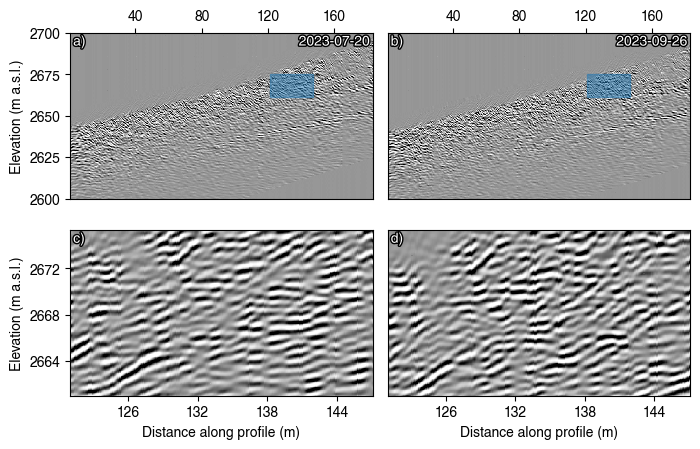

In [27]:
%matplotlib inline

def plot_gpr(da, xx, zz, x0, y0, scale=10):

    from matplotlib.patches import Rectangle
    vmax = np.nanquantile(np.abs(da), 0.99)
    
    # the grid has a 2x2 size, where we plot the before and after gpr images on the left and right
    fig, axs = plt.subplots(2, 2, figsize=(8, 5))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    axs[0, 0].pcolormesh(xx, zz, da.isel(survey=0), cmap='Greys', vmin=-vmax, vmax=vmax, rasterized=True)
    axs[1, 0].pcolormesh(xx, zz, da.isel(survey=0), cmap='Greys', vmin=-vmax, vmax=vmax, rasterized=True)
    
    # the bottom row will be zoomed in
    axs[0, 1].pcolormesh(xx, zz, da.isel(survey=1), cmap='Greys', vmin=-vmax, vmax=vmax, rasterized=True)
    axs[1, 1].pcolormesh(xx, zz, da.isel(survey=1), cmap='Greys', vmin=-vmax, vmax=vmax, rasterized=True)
    
    # we write 'before' and 'after' on the left and right plots
    axs[0, 0].text(0.99, 0.99, '2023-07-20', ha='right', va='top', transform=axs[0, 0].transAxes, c='w', path_effects=pe)
    axs[0, 1].text(0.99, 0.99, '2023-09-26', ha='right', va='top', transform=axs[0, 1].transAxes, c='w', path_effects=pe)
    
    for ax in axs.flatten():
        ax.set_aspect(1)
    
    # we want the right most axis to hide the yticks
    for ax in axs[:, -1]:
        ax.set_yticks([])
    
    # we will zoom in on the bottom row while keeping the aspect ratio
    ylim = axs[0, 0].get_ylim()
    xlim = axs[0, 0].get_xlim()
    yfactor = (ylim[1] - ylim[0]) / scale
    xfactor = (xlim[1] - xlim[0]) / scale
        
    # we plot a rectangle on the top row to show where we zoom in
    for ax in axs[0, :]:
        rect = Rectangle([x0, y0], xfactor, yfactor, ec='tab:blue', facecolor='tab:blue', alpha=0.5)
        ax.add_patch(rect)
    
    # we zoom in on the bottom row
    for ax in axs[-1, :]:
        ax.set_ylim(y0, y0 + yfactor)
        ax.set_xlim(x0, x0 + xfactor)
    
    # we limit the number of x and yticks
    axs[0, 0].yaxis.set_major_locator(plt.MaxNLocator(5))
    axs[1, 0].yaxis.set_major_locator(plt.MaxNLocator(4))
    for ax in axs.flatten():
        ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    
    for ax in axs[:, 0]:
        ax.set_ylabel('Elevation (m a.s.l.)')
        
    for ax in axs[-1, :]:
        ax.set_xlabel('Distance along profile (m)')
    
    for ax in axs[0, :]:
        ax.xaxis.tick_top()

    letters = 'abcd'
    for i, ax in enumerate(axs.flatten()):
        ax.text(0.01, 0.99, letters[i] + ')', ha='left', va='top', transform=ax.transAxes, path_effects=pe, c='w')

    return fig, axs

x0, y0, scale = 121, 2661, 7
xx, zz = np.meshgrid(da1.x, da1.z)
plot_gpr(da1, xx, zz, x0=x0, y0=y0, scale=scale)
plt.gcf().savefig('figures/paper_figures/findelen_mig_zoom.pdf', bbox_inches='tight')
plt.gcf().patch.set_facecolor('none')
plt.gcf().savefig('figures/paper_figures/findelen_mig_zoom.png', bbox_inches='tight')


Load the pre-computed LCC output produced by `run_findelen.py`. Run that script first if the file is not present.

In [28]:
import torch
import io
import pickle

class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else:
            return super().find_class(module, name)

#with open(f'data/findelen_migration/mout_hilbert.p', 'rb') as out:
with open(f'data/findelen_migration/findelen_out.p', 'rb') as out:
    out = CPU_Unpickler(out).load()
    Vhat = out['out']
    lcc = out['lcc']
    losses = out['losses']
    
    print(lcc.f.shape)
    print(out['out'].shape)

torch.Size([1583, 1826])
(21, 2, 395, 456)


In [30]:
lccx, lccz = da1.x[:-3:lcc.stride], da1.z[:-3:lcc.stride]
gprx = lccx
dx = lccx[1] - lccx[0]
dz = lccz[1] - lccz[0]
dx = dx.values / lcc.stride
dz = dz.values / lcc.stride
print(lccx.shape, lccz.shape)
print(dx, dz)

(456,) (395,)
0.09999999999999998 -0.06318412822520258


The coordinates of the flight are stored in this ``.mat`` file.

In [31]:
from scipy.interpolate import interp1d
from scipy.io import loadmat
path = 'Findelen/Findelen_Alexi_gpr_profiles_4.mat'
out = loadmat(path, mat_dtype=True, squeeze_me=True, struct_as_record=False)
data = out['data_gpr_profiles_4']
print(data._fieldnames)

gprx = data.x
gprt = data.t
gprzs = []
for i in range(4):
    z = data.profiles[i].altitude_glacier
    ii = ~np.isnan(z)
    f = interp1d(gprx[ii], z[ii], fill_value='extrapolate')
    gprzs.append(f(lccx))

gprz0 = np.mean(gprzs[:2], axis=0)
gprz1 = np.mean(gprzs[2:], axis=0)

bedx, bedz = np.load('data/findelen_migration/picked_bed.npy')
bedf = interp1d(bedx, bedz, fill_value='extrapolate')
bedz = bedf(lccx)
gprbed = bedz
gprx = lccx

['glacier', 'date', 'antenna_orientation', 'delay', 'npro', 't', 'nppt', 'ntr', 'rot_angle', 'x_0', 'y_0', 'x', 'y', 'East', 'North', 'profiles']


Horizontal and vertical displacement components recovered by the LCC on the real Findelen data.

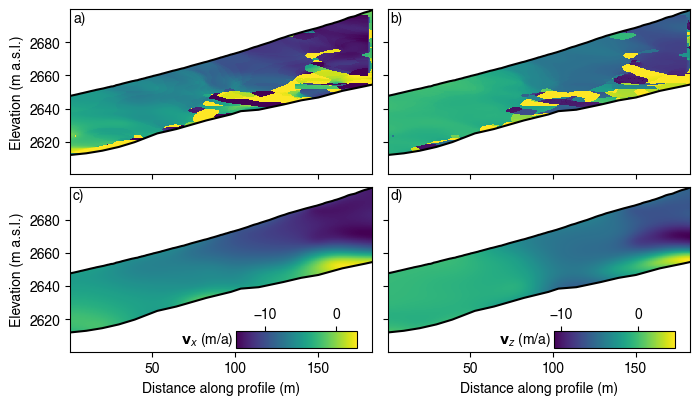

In [32]:
%matplotlib inline

from torch.nn import functional as F
from matplotlib.colors import Normalize

xx, zz = np.meshgrid(lccx, lccz)
under_surface = zz < gprz1
above_bed = zz > bedz
mask = under_surface & above_bed

mask = mask.astype(float)#[:, :-1]
mask[mask == 0] = np.nan    

def plot_field(xx, zz, v, ax, norm):

    #ax.pcolormesh(xx, zz, v, norm=norm, alpha=0.0, rasterized=True)
    im = ax.pcolormesh(xx, zz, v * mask, norm=norm, rasterized=True)
    ax.set_aspect(1)
    ax.set_ylim(zz.min(), zz.max())
    #ax.plot(lccx, gprz0, c='k', lw=1)
    ax.plot(lccx, gprz1, c='k')#, lw=1)
    ax.plot(lccx, bedz, c='k')#, lw=1)
    return im

fig, axs = plt.subplots(2, 2, figsize=(8, 4.5), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.05, hspace=0.05)

Vhatx0 = lcc.subdw.numpy() * dx  / (68 / 365)
#Vhatx0 = F.interpolate(torch.tensor(Vhatx0).reshape(1, 1, *Vhatx0.shape), lcc.f.shape, mode='nearest')[0, 0].numpy()

Vhaty0 = 1.0 * lcc.subdh.numpy() * dz / (68 / 365)
#Vhaty0 = F.interpolate(torch.tensor(Vhaty0).reshape(1, 1, *Vhaty0.shape), lcc.f.shape, mode='nearest')[0, 0].numpy() 

mag0 = np.hypot(Vhatx0, Vhaty0)

Vhatx1 = Vhat[0, 0] * dx  / (68 / 365)
Vhaty1 = 1.0 * Vhat[0, 1] * dz #/ (68 / 365)
mag1 = np.hypot(Vhatx1, Vhaty1)

Vhatx2 = Vhat[-1, 0] * dx / (68 / 365)
Vhaty2 = 1.0 * Vhat[-1, 1] * dz / (68 / 365)
mag2 = np.hypot(Vhatx2, Vhaty2)

xnorm = Normalize(vmin=np.nanmin(Vhatx2 * mask), vmax=np.nanmax(Vhatx2 * mask))
ynorm = Normalize(vmin=np.nanmin(Vhaty2 * mask), vmax=np.nanmax(Vhaty2 * mask))
magnorm = Normalize(vmin=np.nanmin(mag2 * mask), vmax=np.nanmax(mag2 * mask))

plot_field(xx, zz, Vhatx0, axs[0, 0], norm=xnorm)
plot_field(xx, zz, Vhaty0, axs[0, 1], norm=ynorm)

imx = plot_field(xx, zz, Vhatx2, axs[1, 0], norm=xnorm)
imy = plot_field(xx, zz, Vhaty2, axs[1, 1], norm=ynorm)

for ax in axs[-1, :]:
    ax.set_xlabel('Distance along profile (m)')
for ax in axs[:, 0]:
    ax.set_ylabel('Elevation (m a.s.l.)')

bbox = axs[-1, 0].get_position()
cax_length = 0.4 
vxcax = fig.add_axes([bbox.x0 + (0.95 - cax_length) * bbox.width, bbox.y0 + 0.025 * bbox.height, cax_length * bbox.width, 0.1 * bbox.height])
plt.colorbar(imx, cax=vxcax, orientation='horizontal')
vxcax.xaxis.tick_top()
vxcax.text(-0.025, 0.5, '$\mathbf{v}_x$ (m/a)', ha='right', va='center', transform=vxcax.transAxes)

bbox = axs[-1, -1].get_position()
cax_length = 0.4 
vxcax = fig.add_axes([bbox.x0 + (0.95 - cax_length) * bbox.width, bbox.y0 + 0.025 * bbox.height, cax_length * bbox.width, 0.1 * bbox.height])
plt.colorbar(imy, cax=vxcax, orientation='horizontal')
vxcax.xaxis.tick_top()
vxcax.text(-0.025, 0.5, '$\mathbf{v}_z$ (m/a)', ha='right', va='center', transform=vxcax.transAxes)

letters = 'abcdefghijklmnop'
for i, ax in enumerate(axs.flatten()):
    ax.text(0.01, 0.99, f'{letters[i]})', ha='left', va='top', transform=ax.transAxes)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
axs[-1, 0].set_xlabel('Distance along profile (m)')
axs[-1, 0].set_ylabel('Elevation (m a.s.l.)')
fig.savefig('figures/paper_figures/findelen_fields.pdf', bbox_inches='tight')
fig.patch.set_facecolor('none')
fig.savefig('figures/paper_figures/findelen_fields.png', bbox_inches='tight')

"fig.savefig('figures/paper_figures/findelen_fields.pdf', bbox_inches='tight')\nfig.patch.set_facecolor('none')\nfig.savefig('figures/paper_figures/findelen_fields.png', bbox_inches='tight')"

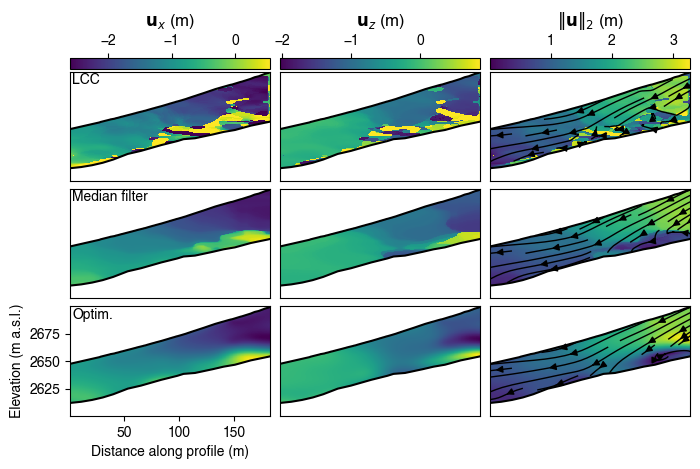

In [33]:
%matplotlib inline

from torch.nn import functional as F
from matplotlib.colors import Normalize

xx, zz = np.meshgrid(lccx, lccz)
under_surface = zz < gprz1
above_bed = zz > bedz
mask = under_surface & above_bed

mask = mask.astype(float)#[:, :-1]
mask[mask == 0] = np.nan    

def plot_field(xx, zz, v, ax, norm):

    #ax.pcolormesh(xx, zz, v, norm=norm, alpha=0.0, rasterized=True)
    im = ax.pcolormesh(xx, zz, v * mask, norm=norm, rasterized=True)
    ax.set_aspect(1)
    ax.set_ylim(zz.min(), zz.max())
    #ax.plot(lccx, gprz0, c='k', lw=1)
    ax.plot(lccx, gprz1, c='k')#, lw=1)
    ax.plot(lccx, bedz, c='k')#, lw=1)
    return im

fig, axs = plt.subplots(3, 3, figsize=(8, 4.5))
fig.subplots_adjust(wspace=0.05, hspace=0.05)

Vhatx0 = lcc.subdw.numpy() * dx # / (120 / 365)
#Vhatx0 = F.interpolate(torch.tensor(Vhatx0).reshape(1, 1, *Vhatx0.shape), lcc.f.shape, mode='nearest')[0, 0].numpy()

Vhaty0 = 1.0 * lcc.subdh.numpy() * dz#/ (120 / 365)
#Vhaty0 = F.interpolate(torch.tensor(Vhaty0).reshape(1, 1, *Vhaty0.shape), lcc.f.shape, mode='nearest')[0, 0].numpy() 

mag0 = np.hypot(Vhatx0, Vhaty0)

Vhatx1 = Vhat[0, 0] * dx # / (120 / 365)
Vhaty1 = 1.0 * Vhat[0, 1] * dz #/ (120 / 365)
mag1 = np.hypot(Vhatx1, Vhaty1)

Vhatx2 = Vhat[-1, 0] * dx #/ (120 / 365)
Vhaty2 = 1.0 * Vhat[-1, 1] * dz# / (120 / 365)
mag2 = np.hypot(Vhatx2, Vhaty2)

xnorm = Normalize(vmin=np.nanmin(Vhatx2 * mask), vmax=np.nanmax(Vhatx2 * mask))
ynorm = Normalize(vmin=np.nanmin(Vhaty2 * mask), vmax=np.nanmax(Vhaty2 * mask))
magnorm = Normalize(vmin=np.nanmin(mag2 * mask), vmax=np.nanmax(mag2 * mask))

plot_field(xx, zz, Vhatx0, axs[0, 0], norm=xnorm)
plot_field(xx, zz, Vhaty0, axs[0, 1], norm=ynorm)
plot_field(xx, zz, mag0, axs[0, 2], norm=magnorm)
axs[0, 2].streamplot(xx, zz[::-1], (Vhatx0 * mask)[::-1], (Vhaty0 * mask)[::-1], color='k', linewidth=1, density=0.6)

plot_field(xx, zz, Vhatx1, axs[1, 0], norm=xnorm)
plot_field(xx, zz, Vhaty1, axs[1, 1], norm=ynorm)
plot_field(xx, zz, mag1, axs[1, 2], norm=magnorm)
axs[1, 2].streamplot(xx, zz[::-1], (Vhatx1 * mask)[::-1], (Vhaty1 * mask)[::-1], color='k', linewidth=1, density=0.6)

imx = plot_field(xx, zz, Vhatx2, axs[2, 0], norm=xnorm)
imy = plot_field(xx, zz, Vhaty2, axs[2, 1], norm=ynorm)
immag = plot_field(xx, zz, mag2, axs[2, 2], norm=magnorm)
axs[2, 2].streamplot(xx, zz[::-1], (Vhatx2 * mask)[::-1], (Vhaty2 * mask)[::-1], color='k', linewidth=1, density=0.6)

axs[0, 0].text(0.01, 0.99, 'LCC', ha='left', va='top', transform=axs[0, 0].transAxes)
axs[1, 0].text(0.01, 0.99, 'Median filter', ha='left', va='top', transform=axs[1, 0].transAxes)
axs[2, 0].text(0.01, 0.99, 'Optim.', ha='left', va='top', transform=axs[2, 0].transAxes)

for i, ax in enumerate(axs.flatten()):
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(zz.min(), zz.max())
    if i != 6:
        ax.set_xticks([])
        ax.set_yticks([])

bbox = axs[0, 0].get_position()
vxcax = fig.add_axes([bbox.x0, bbox.y1 + 0.025 * (bbox.y1 - bbox.y0), bbox.x1 - bbox.x0, 0.1 * (bbox.y1 - bbox.y0)])
plt.colorbar(imx, cax=vxcax, orientation='horizontal')
vxcax.xaxis.tick_top()
vxcax.set_title('$\mathbf{u}_x$ (m)')

bbox = axs[0, 1].get_position()
vycax = fig.add_axes([bbox.x0, bbox.y1 + 0.025 * (bbox.y1 - bbox.y0), bbox.x1 - bbox.x0, 0.1 * (bbox.y1 - bbox.y0)])
plt.colorbar(imy, cax=vycax, orientation='horizontal')
vycax.xaxis.tick_top()
vycax.set_title('$\mathbf{u}_z$ (m)')

bbox = axs[0, 2].get_position()
vmcax = fig.add_axes([bbox.x0, bbox.y1 + 0.025 * (bbox.y1 - bbox.y0), bbox.x1 - bbox.x0, 0.1 * (bbox.y1 - bbox.y0)])
plt.colorbar(immag, cax=vmcax, orientation='horizontal')
vmcax.xaxis.tick_top()
vmcax.set_title('$\Vert \mathbf{u} \Vert_2$ (m)')

axs[-1, 0].set_xlabel('Distance along profile (m)')
axs[-1, 0].set_ylabel('Elevation (m a.s.l.)')
"""fig.savefig('figures/paper_figures/findelen_fields.pdf', bbox_inches='tight')
fig.patch.set_facecolor('none')
fig.savefig('figures/paper_figures/findelen_fields.png', bbox_inches='tight')"""

ssim is 0.5495
mse is 0.10197556763887405


0.3276805583003883

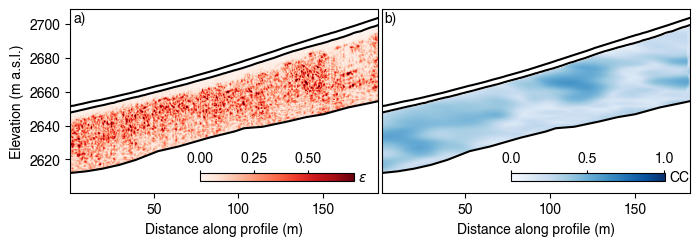

In [ ]:
%matplotlib inline
import numpy as np
import torchfields
import torch
import torch.nn.functional as F
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
import matplotlib.pyplot as plt

def unnormalize(X, shape):
    X[0] = X[0]*shape[1]/2
    X[1] = X[1]*shape[0]/2
    return -X

def normalize(X, shape):
    X[0] = 2*X[0]/shape[1]
    X[1] = 2*X[1]/shape[0]
    return -X

field = torch.stack([lcc.subdw, lcc.subdh])
#field = torch.tensor(out['out'][0], dtype=torch.float)

upsampled_field = F.interpolate(field.reshape(1, *field.shape), lcc.f.shape, mode='bilinear')[0]
normalized_field = normalize(upsampled_field, lcc.f.shape)
tmp = normalized_field.field()(lcc.f)

error = torch.sqrt(torch.square(lcc.g - tmp)[:-3:lcc.stride, :-2:lcc.stride])
ssim = SSIM(sigma=1, return_full_image=True)
score, ssim = ssim(lcc.g.reshape(1, 1, *lcc.g.shape), tmp.reshape(1, 1, *tmp.shape))
print(f'ssim is {1 - score:.4f}')
print(f'mse is {error.mean()}')

vmax = np.nanquantile(np.abs(lcc.g), 0.95)
errmax = np.nanquantile(np.abs(error), 0.99)

fig, axs = plt.subplots(1, 2, figsize=(8, 8 * 10/4))
fig.subplots_adjust(hspace=0.01, wspace=0.01)

axs = axs.flatten()

err_im = axs[0].imshow(error * mask, vmin=0, vmax=errmax, cmap='Reds', 
                       extent=[xx.min(), xx.max(), zz.min(), zz.max()])
cc_im = axs[1].imshow(lcc.convolutions.numpy().max(axis=(0, 1)) * mask, cmap='Blues',
                       extent=[xx.min(), xx.max(), zz.min(), zz.max()], vmin=0, vmax=1.01)

for i, ax in enumerate(axs):
    bbox = ax.get_position()
    cax = fig.add_axes([bbox.x0 + 0.42 * bbox.width, bbox.y0 + 0.025 * bbox.height,
                        0.5 * bbox.width, 0.05 * bbox.height])
    cbar = plt.colorbar([err_im, cc_im][i], cax=cax, orientation='horizontal')
    cax.xaxis.tick_top()
    cax.tick_params('x', length=2)
    cax.text(1.025, 0.5, ['$\epsilon$', 'CC'][i], ha='left', va='center', transform=cax.transAxes)

    cax.yaxis.set_label_position('right')
    #cax.xaxis.set_major_locator(plt.MaxNLocator(5))

#axs[0].text(0.01, 0.99, '$||\hat{g} - g||_2$', ha='left', va='top', transform=axs[0].transAxes)
ax#s[1].text(0.01, 0.99, '$\hat{C}_\mathrm{max}$', ha='left', va='top', transform=axs[1].transAxes)
axs[1].set_yticks([])

for i, ax in enumerate(axs):
    ax.plot(gprx, gprz0, c='k')
    ax.plot(gprx, gprz1, c='k')
    ax.plot(gprx, gprbed, c='k')
    ax.set_aspect(1)
    ax.set_xlabel('Distance along profile (m)')
    ax.text(0.01, 0.99, 'ab'[i] + ')', ha='left', va='top', transform=ax.transAxes)#, size='large')

axs[0].set_ylabel('Elevation (m a.s.l.)')
fig.patch.set_facecolor('none')
fig.savefig('figures/paper_figures/findelen_error.pdf', bbox_inches='tight')
fig.savefig('figures/paper_figures/findelen_error.png', bbox_inches='tight')


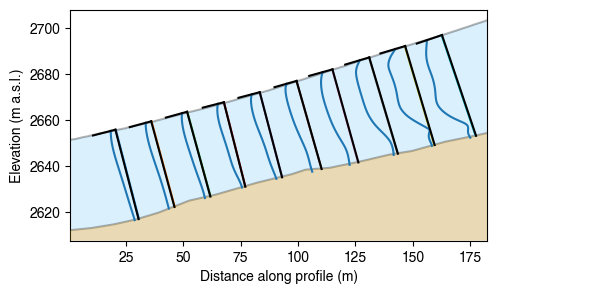

In [ ]:

%matplotlib inline
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
import mpl_toolkits.axisartist.floating_axes as floating_axes
from matplotlib.transforms import Affine2D

n_samples = 10 
surface_points = np.linspace(50, len(gprx) - 51, n_samples).astype(int)

Vhatx2 = Vhat[-1, 0] * dx #/ (120 / 365)
Vhaty2 = 1.0 * Vhat[-1, 1] * dz# / (120 / 365)
mag2 = np.hypot(Vhatx2, Vhaty2)

velocity_magnitude = np.hypot(Vhatx2, Vhaty2)  # Magnitude of velocity

velocity_interpolator = RegularGridInterpolator((xx[0], zz[::-1, 0]),  
                                                velocity_magnitude[::-1].T,
                                                bounds_error=False,
                                                fill_value=np.nan)

depth_points = 100  
velocity_profiles = []
profile_lines = []  

for idx in surface_points:
    
    # surface point
    x_s, z_s = gprx[idx], gprz0[idx]

    normal_slope = -1.0 / np.gradient(gprz0, gprx)[idx]

    # the way the perpendicular is found here is different, worked better than on the smooth surface from last time
    distances_to_normal = np.abs(gprbed - (normal_slope * (gprx - x_s) + z_s)) / np.sqrt(normal_slope**2 + 1)
    closest_idx = distances_to_normal.argmin()
    x_b, z_b = gprx[closest_idx], gprbed[closest_idx]

    line_x = np.linspace(x_s, x_b, depth_points)
    line_z = np.linspace(z_s, z_b, depth_points)
    profile_lines.append((line_x, line_z))
    
    sampled_velocities = velocity_interpolator(np.array([line_x, line_z]).T)
    velocity_profiles.append(sampled_velocities)


fig, ax = plt.subplots(figsize=(5.4, 3))
ax.set_aspect(1)
ax.plot(gprx, gprz0, color='k', alpha=0.3)
ax.plot(gprx, gprbed, color='k', alpha=0.3)# marker='.')
ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.fill_between(gprx, gprz0, gprbed, fc='lightskyblue', alpha=0.3)
ax.fill_between(gprx, ylim[0], gprbed, fc='darkgoldenrod', alpha=0.3, zorder=10)
ax.set_xlim(gprx.min(), gprx.max())

for i, line in enumerate(profile_lines):
    line_x, line_z = line

    ax.plot(line_x, line_z)
    
    DX = line_x[-1] - line_x[0]
    DZ = line_z[-1] - line_z[0]
    angle = np.arctan2(DZ, DX) 

    width =  0.1 * (ax.get_xlim()[1] - ax.get_xlim()[0])  
    profile_length = np.sqrt(DX**2 + DZ**2)
    height = profile_length

    x0 = np.array([line_x.mean(), line_z.mean()])
    w0 = np.array([width, height])

    x, y = fig.transFigure.inverted().transform(ax.transData.transform(x0))
    xo, yo = fig.transFigure.inverted().transform(ax.transData.transform(x0 + w0))
    h0 = w0 = np.sqrt((xo - x) ** 2 + (yo - y) ** 2)    
    
    xmin, xmax = -1., 1.                             
    ymin, ymax = -1., 1.                        
    transform = Affine2D().rotate(angle + np.pi/2)
    helper = floating_axes.GridHelperCurveLinear(transform, (xmin, xmax, ymin, ymax))
    ax2 = floating_axes.FloatingSubplot(fig, 111, grid_helper=helper, zorder=0)
    
    R = transform.transform([(x - w0 / 2, y - h0 / 2),
                             (x + w0 / 2, y - h0 / 2),
                             (x - w0 / 2, y + h0 / 2),
                             (x + w0 / 2, y + h0 / 2),])
    
    w1 = R[:, 0].max() - R[:, 0].min()                
    h1 = R[:, 1].max() - R[:, 1].min()                  

    ax2.set_position((x - w1 / 2, y - h1 / 2, w1, h1))
    fig.add_subplot(ax2)    
    ax2_aux = ax2.get_aux_axes(transform)

    for spine in ['bottom', 'right', 'top', 'left']:
        ax2.axis[spine].set_visible(False)
    ax2.patch.set_visible(False)
    ax2_aux.plot(-1.0 * velocity_profiles[i]/np.max(velocity_profiles)/2, np.linspace(1, -1, depth_points))

    ax2_aux.plot([-0.5, 0], [1.0, 1.0], c='k')
    ax2_aux.plot([0, 0], [-1, 1], c='k')
           
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('Elevation (m a.s.l.)')

fig.savefig('figures/paper_figures/findelen_vprofiles.pdf', bbox_inches='tight')
fig.patch.set_facecolor("none")
fig.savefig('figures/paper_figures/findelen_vprofiles.png', bbox_inches='tight')
